In [254]:
import numpy as np
import matplotlib.pyplot as plt


In [255]:
# Momentum
def P(M, m1, m2):
    p1=np.sqrt(M**2+m1**2-m2**2)/(2*M)
    p2=np.sqrt(M**2+m2**2-m1**2)/(2*M)
    return (p1+p2)/2/M


In [256]:
a = P(3.0969, 0.000511, 0.000511)
print(a)


0.16145177435500016


In [257]:
# Angles and vectors of momentum

def angles():
    phi=np.random.uniform(0, 2*np.pi)
    costheta=np.random.uniform(-1, 1)
    theta=np.arccos(costheta)
    return phi, theta

def momentum_vectors(p, phi, theta):
    px=p*np.sin(theta)*np.cos(phi)
    py=p*np.sin(theta)*np.sin(phi)
    pz=p*np.cos(theta)
    return np.array([px, py, pz])

def generator(M, m1, m2):
    p=P(M, m1, m2)
    theta, phi = angles()
    p1=momentum_vectors(p, phi, theta)
    p2=-p1
    return p1, p2


In [258]:
def invariant_mass(p1, p2, m1, m2):
    E1=np.sqrt(np.sum(p1**2)+m1**2)
    E2=np.sqrt(np.sum(p2**2)+m2**2)
    
    p=p1+p2
    E=E1+E2
    m=E**2-np.dot(p, p)
    return np.sqrt(m)


In [259]:
# Masses in GeV and definitions of the decays

masses = {'pion': 0.13957, 'muon': 0.10566, 'kaon': 0.49368, 'proton': 0.93827, 'jpsi': 3.0969, 'psi2s': 3.6861}

def rho2pi():
    return generator(masses['rho'], masses['pion'], masses['pion'])

def jpsi2muon2():
    return generator(masses['jpsi'], masses['muon'], masses['muon'])

def psi2s2muon2():
    return generator(masses['psi2s'], masses['muon'], masses['muon'])

def pp_interaction():
    return generator(masses['proton'], masses['proton'], masses['proton'])


In [260]:
# Photon interaction to lepton pair

def gg2ll(m_gamma, m_lepton1, m_lepton2):
    return generator(m_gamma, m_lepton1, m_lepton2) 


In [261]:
def qa_plot_dedx_p(p_list, dedx_list):
    plt.figure(figsize=(8, 6))
    plt.scatter(p_list, dedx_list, s=3)
    plt.xlabel('$p [GeV]$')
    plt.ylabel('dE/dx [a.u.]')
    plt.show()


In [262]:
def qa_plot_invariant_masses(mass):
    plt.figure(figsize=(8, 6))
    
    if np.min(mass) == np.max(mass):
        # sztuczny mały zakres – plotuje bez błędu
        small = np.min(mass)
        bins = np.linspace(small - 0.001, small + 0.001, 50)
        plt.hist(mass, bins=bins)
    else:
        plt.hist(mass, bins=50)
    
    plt.xlabel('invariant mass [GeV]')
    plt.ylabel('counts')
    plt.show()


In [263]:
# Event gereration and plotting qa plots of invariant mass distributin and pT distribution

def event_generator(decay, N=10000):
    momentum = []
    mass_list = []
    if decay == "jpsi":
        m1 = m2 = 0.10566
    elif decay == "rho":
        m1 = m2 = 0.13957
    elif decay == "psi2s":
        m1 = m2 = 0.10566
    elif decay == "pp":
        m1 = m2 = 0.93827
    else:
        raise ValueError("Unknown decay")
    for _ in range(N):
        if decay == "rho":
            p1, p2= rho2pi()
            mass =masses['rho']
        elif decay == "jpsi":
            p1, p2=jpsi2muon2()
            mass= masses['jpsi']
        elif decay == "psi2s":
            p1, p2 = psi2s2muon2()
            mass = masses['psi2s']
        elif decay == "pp":
            p1, p2 = pp_interaction()
            mass = masses['proton']
        else: raise ValueError("Unknown decay")
        
        p=np.linalg.norm(p1)
        momentum.append(p)
        m_inv = invariant_mass(p1, p2, m1, m2)
        mass_list.append(m_inv)
    return np.array(momentum), np.array(mass_list)


ValueError: Too many bins for data range. Cannot create 50 finite-sized bins.

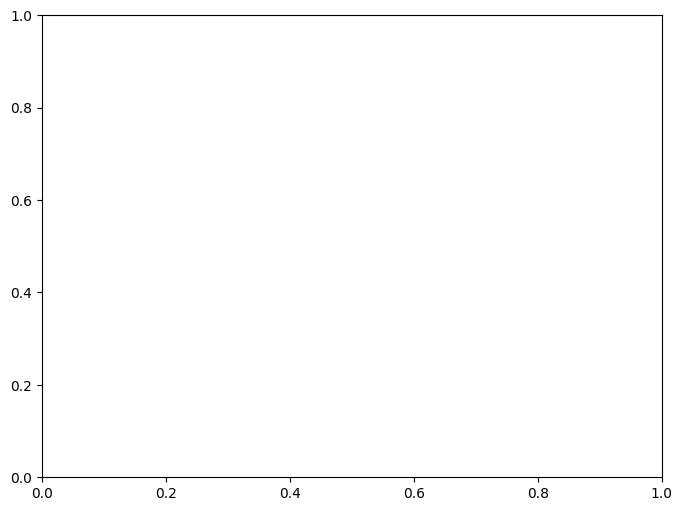

In [264]:
p, mass = event_generator("jpsi", N=10000)
qa_plot_invariant_masses(mass)
